In [1]:
import numpy as np
from astropy.table import Table, vstack
import astropy.units as u

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Ellipse

In [2]:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import RandomForestRegressor

In [3]:
import os, sys, time, gc
from importlib import reload

In [4]:
rng = np.random.default_rng()

In [5]:
hdir = os.getenv("HOME")
pdir = os.getenv("PSCRATCH")

In [6]:
# Adding friendly to the path so we can import it in the next cell

sys.path.insert(1, f'{hdir}/codes/friendly/friendly')
sys.path.insert(1, f'{hdir}/codes/friendly')

In [7]:
import friendly
reload(friendly)
from friendly.utils import FCatalog
from friendly.matchers.ellipses import FEllipse
from friendly.matchers.kdtree import FKDTree
from friendly.pruners.mag_diff import MagDiffPruner

In [8]:
%config InlineBackend.figure_format='retina'

In [9]:
plt.style.use('ggplot')

In [10]:
def fblend_generic_1d(gen_row, blend_row, add_filt=None, b_bins=None, Nbin=50, min_size=10):
    '''
    Helper function to calculate fraction of unrecognized blend as a function of `gen_row` binning.

    `gen_row` : Generic row. Any array of the same length as `blend_row` that has a variable we want to bin on
    `blend_row` : Blend label row. Array of booleans labelling an object as pure (0) or blended (1)
    `add_filt` : Additional filter. Any additional filter that should be applied along with binning. Default is no additional filter
    `b_bins` :  Blend bins. User supplied binning of `gen_row.` If no bins are provided, automatically create from minimum to maximum of `gen_row` with `Nbin` bins
    `Nbin` : Number of bins. When using automatic binning, the number of bins to use. 
    '''
    # gen_row is any measurement with the same size of blend_row

    if b_bins is None:
        b_bins = np.linspace(gen_row.min(), gen_row.max(), Nbin)
    else:
        Nbin = len(b_bins)
    
    f_blend_mag = np.zeros(Nbin)
    f_blend_err = np.zeros_like(f_blend_mag)
    f_bins = np.zeros_like(f_blend_mag)
    
    # b_bins = np.linspace(14.5, 30, 50)
    f_bins = b_bins
    b_digitize = np.digitize(gen_row, b_bins)

    num_bin = len(b_bins)
    
    for ndx in range(1, num_bin+1):
        if add_filt is None:
            filt = (b_digitize==ndx)
        else:
            filt = (b_digitize==ndx) * add_filt
        if (np.sum(filt)<=min_size):
            continue
        # num_blends = np.sum(obj_tract[filt]['unrec_blend_score'] > unrec_cutoff)
        num_blends = np.sum(blend_row[filt])
        num_objs = np.sum(filt)

        f_blend_mag[ndx-1] = num_blends/num_objs
        # Treating num_blends and num_objs as independent poisson
        f_blend_err[ndx-1] = (num_blends + num_blends ** 2 * num_objs / num_objs ** 2) ** (1 / 2) / num_objs
    
    return {'fraction': f_blend_mag, 'err': f_blend_err, 'bins': f_bins}

# Load in Data

In [11]:
def apply_box(table, bbox, RA='RA', DEC='DEC'):
    # bbox = [lower ra, upper ra, lower dec, upper dec]
    ra_filt = np.logical_and(table[RA] > bbox[0], table[RA] < bbox[1])
    dec_filt = np.logical_and(table[DEC] > bbox[2], table[DEC] < bbox[3])
    bbox_filt = np.logical_and(ra_filt, dec_filt)

    table_subset = table[bbox_filt]
    return table_subset

In [12]:
subaru = Table.read(pdir + '/data/cos_NFP.fits')
HST_all = Table.read(pdir + '/data/acs.fits')
HST = HST_all[HST_all['flags']==0]

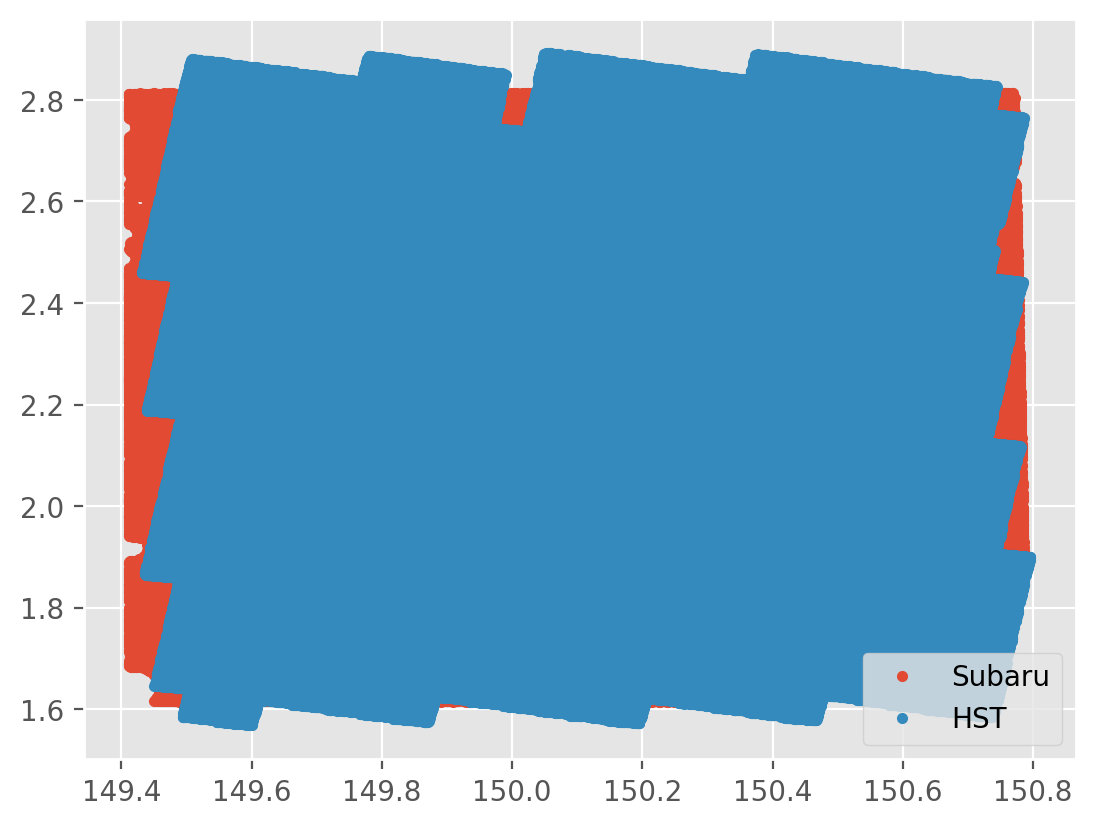

In [13]:
plt.plot(subaru['ALPHA_J2000'], subaru['DELTA_J2000'], '.', label='Subaru')
plt.plot(HST['ra'], HST['dec'], '.', label='HST')
plt.legend()

In [14]:
subaru = Table.read(pdir + '/data/cos_NFP.fits')
HST_all = Table.read(pdir + '/data/acs.fits')
HST = HST_all[HST_all['flags']==0]

In [16]:
# Matching on the whole data is slow since friendly is not very scalable code (currently)

# Running on a tiny subset to show that basic ideas and then remove this to get the full
# matched catalog

bbox = [149.6, 150.0, 1.65, 2.0]
# bbox = [149.6, 149.7, 1.8, 1.9]

subaru = apply_box(subaru, bbox, 'ALPHA_J2000', 'DELTA_J2000')
HST = apply_box(HST, bbox, 'ra', 'dec')
shuang_subset = apply_box(shuang_matched, bbox, 'ALPHA_J2000', 'DELTA_J2000')

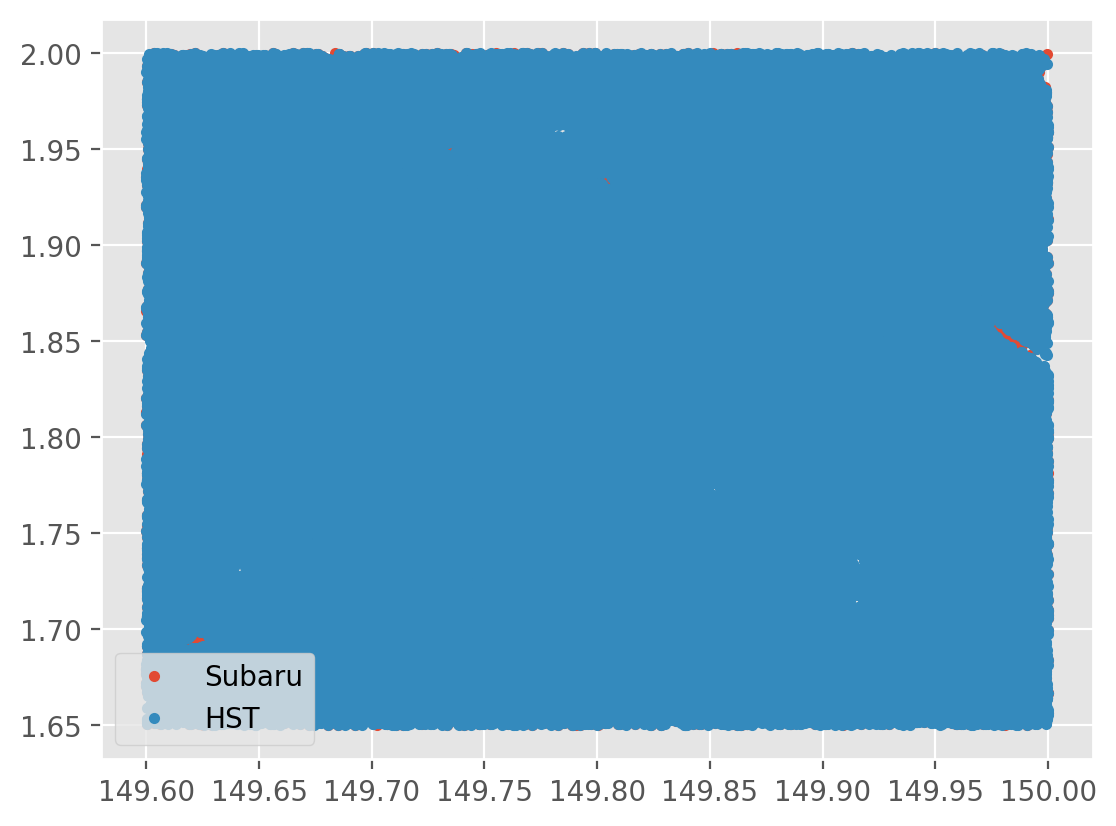

In [17]:
plt.plot(subaru['ALPHA_J2000'], subaru['DELTA_J2000'], '.', label='Subaru')
plt.plot(HST['ra'], HST['dec'], '.', label='HST')
plt.legend()

In [18]:
# shuang_subaru = Table.read(pdir + '/data/cos_NFPMM_newspec.fits')
# shuang_subaru = apply_box(shuang_subaru, bbox, 'ALPHA_J2000', 'DELTA_J2000')

### Catalog Set-up

Our catalog needs to be modified a bit to get things to work with friendly. 

In [19]:
subaru['fluxrad_arcsec'] = subaru['FLUX_RADIUS'] * 0.2 # Convert from pixels to arcseconds

In [20]:
# Add indexes 

subaru.add_index("NUMBER")
HST.add_index("ID")

In [21]:
# Add "ellipse" parameters (A,B, Theta) that are in units of DEGREES

# These input catalogs do not have shape paramters included so 
# we are doing the second best thing and just drawing circles (A=B=R)
# Ideally we should be using actual shape measurements to draw real ellipses
# in this section
subaru['A'] = subaru['fluxrad_arcsec'] * 1/60.**2
HST['A'] = HST['flux_radius_to_cos'] * 1/60.**2

subaru['B'] = subaru['fluxrad_arcsec'] * 1/60.**2
HST['B'] = HST['flux_radius_to_cos'] * 1/60.**2
subaru['theta'] = 0
HST['theta'] = 0

In [22]:
# Insert into the Friendly Catalog wrapper
subaru_fc = FCatalog(subaru, "NUMBER")
HST_fc = FCatalog(HST, "ID")

# Generate Candidate Matches

We use spatial coordinates and ellipse information to generate a list of candidate unrecognized blends.
The Ellipse matcher `FEllipse` starts by using a coarse positional search (`search_rad`) that it can then iterate over to find the actual galaxies with ellipse overlap.
When calculating the ellipse overlap, it helps to add a `scale` factor to the `A`/`B` terms of the ellipse since these can only capture the half-light radius which might not be enough!

In [23]:
reload(sys.modules['friendly.matchers.ellipses'])
reload(sys.modules['friendly.matchers.kdtree'])
from friendly.matchers.ellipses import FEllipse
from friendly.matchers.kdtree import FKDTree

In [24]:
ellipse_matcher = FEllipse(tune_params = {'search_rad': 5/(60.**2)})
kdtree_matcher = FKDTree(tune_params = {'search_rad': 1/(60.**2)})

In [25]:
# friendly functions use a parameter dictionary to map
# from the data needed to the columns in the catalogs provided.
# _____1 refers to the first catalog and _____2 for the second.
# This should be updated to be _ground and _space (or _truth) for clarity


ellipse_params = {'RA1': 'ALPHA_J2000', 'DEC1': 'DELTA_J2000',
                  'RA2': 'ra', 'DEC2': 'dec',
                  'A1': 'A', 'B1': 'B', 'THETA1': 'theta',
                  'A2': 'A', 'B2': 'B', 'THETA2': 'theta'}

start = time.time()
ellipse_groups, _ = ellipse_matcher(subaru_fc, HST_fc, ellipse_params, scale=1.5)
end = time.time()

print(f"Total time: {(end-start):0.2f}")

starting ellipse params [ 1.82617591e-13  1.82617591e-13 -0.00000000e+00 -2.73779938e-11
 -3.46302652e-13  4.10516022e-09]
Total time: 19.41


In [26]:
kdtree_params = {'RA1': 'ALPHA_J2000', 'DEC1': 'DELTA_J2000',
                  'RA2': 'ra', 'DEC2': 'dec' }

start = time.time()
kdtree_groups, _ = kdtree_matcher(subaru_fc, HST_fc, kdtree_params)
end = time.time()

print(f"Total time: {(end-start):0.2f}")

Total time: 4.62


# Prune

Using the list of candidates, we can prune this list based on what we define as blends. 
For us these are objects that are brighter than some space magnitude $m_s = 26.5$ and are within 2 magnitudes of the ground object.
Check out [this Technote](sitcomtn-128.lsst.io) for some more details or [the paper](https://arxiv.org/abs/2503.16680).

In [36]:
reload(sys.modules['friendly.pruners.mag_diff'])
from friendly.pruners.mag_diff import MagDiffPruner

In [37]:
mprune = MagDiffPruner({'ground_mag_limit': 24.6, 'space_mag_limit': 26.5, 'delta_mag_limit': 2})

In [ ]:
# This will be quite slow!
# This might also have a memory leak...

pruned_groups = mprune(subaru_fc, HST_fc,
                       {'ground_mag_name': 'ip', 'space_mag_name': 'mag_best'},
                       ellipse_groups)

# Blend Plot

In [40]:
# These should be added to friendly at some point....

def add_match_group(table, groups, match_name):
    # Add the candidate groups to the table
    ndx1_name = match_name + '_idx1'
    ndx2_name = match_name + '_idx2'

    ndx1s = []
    ndx2s = []
    for i in groups:
        ndx1s.append(i.idx1)
        ndx2s.append(i.idx2)
    table[ndx1_name] = ndx1s
    table[ndx2_name] = ndx2s

    return None

In [41]:
add_match_group(subaru, pruned_groups, 'ellipse')
add_match_group(subaru, kdtree_groups, 'kdtree')

In [42]:
blend_bool_ellip = np.array([len(s2) - len(s1) for s1, s2 in zip(subaru['ellipse_idx1'], subaru['ellipse_idx2'])])
blend_bool_kdtree = np.array([len(s2) - len(s1) for s1, s2 in zip(subaru['kdtree_idx1'], subaru['kdtree_idx2'])])

In [43]:
subaru['ellipse_blend'] = blend_bool_ellip
subaru['kdtree_blend'] = blend_bool_kdtree

In [44]:
imag_bins = np.arange(18, 25.5, .5)

eblend_dict = fblend_generic_1d(subaru['ip'], subaru['ellipse_blend'] > 0, b_bins=imag_bins,
                                add_filt=subaru['ellipse_blend']>=0)
kdblend_dict = fblend_generic_1d(subaru['ip'], subaru['kdtree_blend'] > 0, b_bins=imag_bins,
                                add_filt=subaru['kdtree_blend']>=0)

Text(0.5, 1.0, 'Subaru x HST Unrecognized Blends')

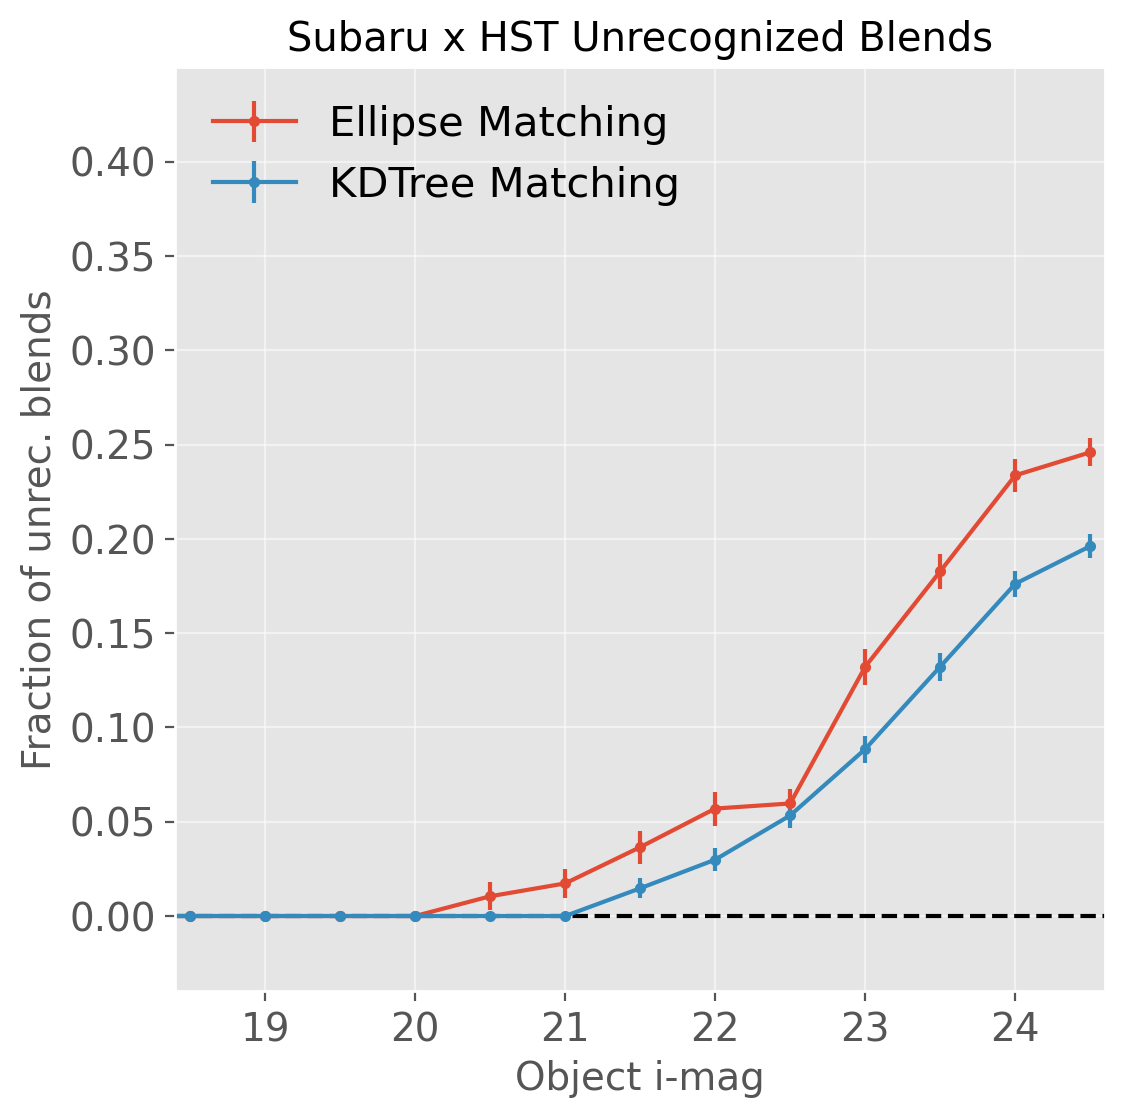

In [46]:
# Plot with errorbars
fig,ax = plt.subplots(1, figsize=(6,6))

ytop = .45 # Set this after looking at the plot to make it prettier
ax.errorbar(eblend_dict['bins'][:-1], eblend_dict['fraction'][:-1],
            yerr=eblend_dict['err'][:-1], marker='.', ls='-', label='Ellipse Matching')
ax.errorbar(kdblend_dict['bins'][:-1], kdblend_dict['fraction'][:-1],
            yerr=kdblend_dict['err'][:-1], marker='.', ls='-', label='KDTree Matching')

# ax.legend(frameon=False, bbox_to_anchor=(1.2, .6))
# ax.set_ylim(top=1.0, bottom=.7)
ax.set_ylabel("Fraction of unrec. blends", fontsize=14)
ax.set_xlabel("Object i-mag", fontsize=14);
ax.set_xlim(18.4, 24.6)
ax.set_ylim(-.04, ytop)
# ax.legend(frameon=False, bbox_to_anchor=(1.4,.5))
ax.legend(loc='upper left', fontsize=15, frameon=False)
ax.set_yticks(np.arange(0,ytop,.05))
ax.axhline(0, ls='--', color='black')
for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
ax.grid(visible=True, alpha=0.5)
ax.set_title("Subaru x HST Unrecognized Blends")
# ax.set_title(f"Matching with {min_mag} Magnitude Cutoff and {mag_cutoff} Difference Cutoff")

### Blend Entropy

# Old Prune Code...

In [105]:
# Set of helper functions to do the pruning. You probably don't need to mess with these too much.
# This will be added to friendly at some point...


def mag_remove_id(table, mag_limit, mag_name, ndx_name='objectId'):
    # Remove entries from table that have mag_name > mag_limit
    mag_filt = table[mag_name] < mag_limit
    remove_oids = table[ndx_name][~mag_filt]
    return remove_oids

def table_removerows(table, remove_oids, ndx_name='objectId'):
    # Remove rows from a table. This gets rid of objects we don't want to study
    # when looking at population statistics but should be included in matching
    
    # Might want to think if this should be done in-place or returning a copy?
    remove_ndx = np.array([not (ndx in remove_oids) for ndx in table[ndx_name]])
    with table.index_mode('copy_on_getitem'):
        removed_table = table[remove_ndx]
    return removed_table

def table_remove_from_matches(table, remove_oids, match_name):
    # Remove entries from matches.
    
    # Might want to use set() or some other datatype to make this more
    # efficient but only relevant if this is too slow
    for i in table[match_name]:
        if len(i) > 0:
            for j in i:
                if j in remove_oids:
                    i.remove(j) a#Python lists are actually convenient here!
    return None

def table_purge(table, remove_oids, match_name, ndx_name='objectId'):
    # Remove entries from matches and the rows of the table.
    removed_table = table_removerows(table, remove_oids, ndx_name)
    table_remove_from_matches(removed_table, remove_oids, match_name)
    return removed_table

def ndx2_magdiff(table, ndx2_table, match_name, mag2_name, mag_diff=2):
    # Given indexes, get the magnitudes and filter anything that is more than
    # mag_diff away from the brightest space match.
    for i,v in enumerate(table[match_name]):
        if len(v) > 1:
            ndx2_mags = ndx2_table.loc[v][mag2_name]
            ndx2_diffs = ndx2_mags - ndx2_mags.min()
            good_filt = ndx2_diffs <= mag_diff
            table[match_name][i] = [m for m,g in zip(v, good_filt) if g]
    return None

def ndx2_magdiff2(table, ndx2_table, match_name, mag1_name, mag2_name, mag_diff=2):
    # Given indexes, get the magnitudes and filter anything that is more than
    # mag_diff away from the ground object.
    for i,v in enumerate(table[match_name]):
        if i%1000==0:
            print(f"On {i}", end="\r")
        if len(v) > 1:
            ndx2_mags = ndx2_table.loc[v][mag2_name]
            ndx2_diffs = ndx2_mags - table[i][mag1_name]
            good_filt = ndx2_diffs <= mag_diff
            table[match_name][i] = [m for m,g in zip(v, good_filt) if g]
    return None

def get_unrecbl_table(table, space_table, method, ground_lim, space_lim,
                      ground_mag='i_mag', space_mag='F814_MAG',
                      ground_id='objectId', space_id='ID'):
    # Get ground objects that have no space match
    nomatch_remove_oids = np.array([k[ground_id] for k in table if len(k[f'{method}_idx2'])==0]) # Should turn this into a function...
    # Remove unmatched ground objects from the rows but not the matches!
    small_table = table_removerows(table, nomatch_remove_oids, ndx_name=ground_id)

    # Remove faint and non-matches from table
    # small_table = table_purge(table, all_roids, f'{method}_idx1', ndx_name=ground_id)

    # Get space objects in table that are fainter than space_lim
    hst_roids = mag_remove_id(space_table, space_lim, space_mag, ndx_name=space_id)
    # Remove faint space objects
    table_remove_from_matches(small_table, hst_roids, f'{method}_idx2')
    # Remove entries where the matched objects have more than 2 mag difference 
    # ndx2_magdiff2(small_table, space_table, f'{method}_idx2', mag1_name=ground_mag, mag2_name=space_mag)
    ndx2_magdiff(small_table, space_table, f'{method}_idx2', mag2_name=space_mag)
    # Label blends
    unrec_bl = np.array([len(k[f'{method}_idx2']) - len(k[f'{method}_idx1']) for k in small_table])
    small_table[f'{method}_blend'] = unrec_bl
    return small_table

In [24]:
add_match_group(subaru, ellipse_groups, 'ellipse')
# add_match_group(comcam_table, fof_groups_cc_hst, 'ellipse') # Nee

In [25]:
# This is MUCH slower!

start = time.time()
ellipse_table = get_unrecbl_table(subaru, HST, 'ellipse', 24.5, 26.5,
                                  ground_mag='ip', ground_id='NUMBER',
                                  space_mag='mag_best', space_id='ID')
end = time.time()
print(f"Total time: {(end-start):0.2f}")

Total time: 41.70


There is an issue with saving this table directly, so we break it up into two parts which works? This should be updated somepoint soon

In [26]:
# all_columns = ellipse_table.colnames
# clean_columns = all_columns[:-3] + [all_columns[-1]]

# ellipse_table_noid = ellipse_table[clean_columns]
# ellipse_table_noid.write(pdir+'/data/friendly/subaru_hst_noids.fits', format='fits', overwrite=True)

# id_table = ellipse_table['ellipse_idx1', 'ellipse_idx2']
# id_table.write(pdir+'/data/friendly/subaru_hst_ids.csv', format='pandas.csv', overwrite=True)

In [27]:
ellipse_blends = (ellipse_table['ellipse_blend'] > 0).astype(int)

### Random Forest

Now that we have a labelled catalog we can create a classifier. Let's stick with the Random Forest for now!

In [28]:
def get_costrecall(test_scores, blend_filt):
    tlen = len(test_scores)

    thresholds = np.linspace(0,1,101)
    cost = np.zeros(101)
    recall = np.zeros(101)

    for i, thresh in enumerate(thresholds):
        pred_blends = test_scores > thresh

        cost[i] = np.sum(pred_blends)/tlen
        recall[i] = np.sum(pred_blends[blend_filt])/np.sum(blend_filt)
    return cost, recall, thresholds

In [29]:
def get_split(sample, train_frac=0.5):
    # Split each sub-sample into a training + testing split
    N = len(sample)
    # Weighting the random choice between True and False by the 
    # `train_frac` input. 
    train_ndx = rng.choice([True, False], size=N, p=[train_frac, 1-train_frac])
    train = sample[train_ndx]
    test = sample[~train_ndx]
    return train, test

In [30]:
def colorify(sample):
    # Turn photometry into colors using constant aperture.
    # Should update this to use the Asinh magnitudes....
    # sample['uB'] = -2.5 * np.log10(sample['u_FLUX_APER3'] / sample['B_FLUX_APER3'])
    # sample['BV'] = -2.5 * np.log10(sample['B_FLUX_APER3'] / sample['V_FLUX_APER3'])
    # sample['Vr'] = -2.5 * np.log10(sample['V_FLUX_APER3'] / sample['r_FLUX_APER3'])
    # sample['ri'] = -2.5 * np.log10(sample['r_FLUX_APER3'] / sample['ip_FLUX_APER3'])
    # sample['iz'] = -2.5 * np.log10(sample['ip_FLUX_APER3'] / sample['zpp_FLUX_APER3'])
    # sample['zY'] = -2.5 * np.log10(sample['zpp_FLUX_APER3'] / sample['Y_FLUX_APER3'])
    # sample['YJ'] = -2.5 * np.log10(sample['Y_FLUX_APER3'] / sample['J_FLUX_APER3'])
    # sample['JH'] = -2.5 * np.log10(sample['J_FLUX_APER3'] / sample['H_FLUX_APER3'])

    sample['uB'] = (sample['u_MAG_AUTO'] - sample['B_MAG_AUTO'])
    sample['BV'] = (sample['B_MAG_AUTO'] - sample['V_MAG_AUTO'])
    sample['Vr'] = (sample['V_MAG_AUTO'] - sample['r_MAG_AUTO'])
    sample['ri'] = (sample['r_MAG_AUTO'] - sample['ip_MAG_AUTO'])
    sample['iz'] = (sample['ip_MAG_AUTO'] - sample['zpp_MAG_AUTO'])
    sample['zY'] = (sample['zpp_MAG_AUTO'] - sample['Y_MAG_AUTO'])
    sample['YJ'] = (sample['Y_MAG_AUTO'] - sample['J_MAG_AUTO'])
    sample['JH'] = (sample['J_MAG_AUTO'] - sample['H_MAG_AUTO'])
    sample['i'] = sample['ip_MAG_AUTO']
    return None

In [31]:
# Break into blend + pure sample to further divide 
# into the training + testing samples

blends = ellipse_table[np.logical_and(ellipse_table['ellipse_blend'] > 0, ellipse_table['ip_MAG_AUTO'] <=24.5)]
pure = ellipse_table[np.logical_and(ellipse_table['ellipse_blend'] <= 0, ellipse_table['ip_MAG_AUTO'] <=24.5)]

blend_train, blend_test = get_split(blends)
pure_train, pure_test = get_split(pure)

In [32]:
train = vstack((blend_train, pure_train))
test = vstack((blend_test, pure_test))

In [33]:
colorify(train)
colorify(test)

In [34]:
# We only want the Photometry + Flux Radius 

photom_labels = ['uB', 'BV', 'Vr', 'ri', 'iz', 'zY', 'YJ', 'JH', 'i', 'FLUX_RADIUS'] # Better to use colors but not necessary
# photom_labels = ['u', 'B', 'V', 'r', 'ip', 'zpp', 'Y', 'J', 'H', 'FLUX_RADIUS']

In [35]:
# sklearn doesn't play well with astropy Tables :( 
train_photom = train[photom_labels].to_pandas()
test_photom = test[photom_labels].to_pandas()

train_lbl = (train['ellipse_blend'] > 0).astype(int) # True if it is a blend
test_lbl = (test['ellipse_blend'] > 0).astype(int) # True if it is a blend

In [36]:
# Initialize an classifier
clf = RandomForestClassifier(n_estimators=100, criterion='gini')

# Fit the classifier on the training data + labels
clf.fit(train_photom, train_lbl)

RandomForestClassifier()

Now that we have a classifier, we can assign each object a category -- either "pure" or "blend." However, due to the imbalanced dataset, the classifier will almost always want to just guess "pure"! We can instead ask for the fraction of Trees that voted for blend via `predict_proba` and place a threshold cut on that.

So if we place the cut at 0.3, we require that $ \geq 30$ trees voted for blend. More generically, a cut placed at $c$ in a forest with $N$ trees needs $\geq \lceil c \times N \rceil$ votes to be labelled as a blend.

In the plot below (and the main figure in [the paper](https://arxiv.org/abs/2503.16680)), we vary the threshold $c$ and see how much of the entire sample is labelled as a blend (cost) and how much of the blends are labelled as blends.

In [37]:
test_scores1 = clf.predict_proba(test_photom)
c2, r2, thresh = get_costrecall(test_scores1[:,1], test_lbl.astype(bool))

In [38]:
# ndx = 38
# print(thresh[ndx], c2[ndx], r2[ndx])

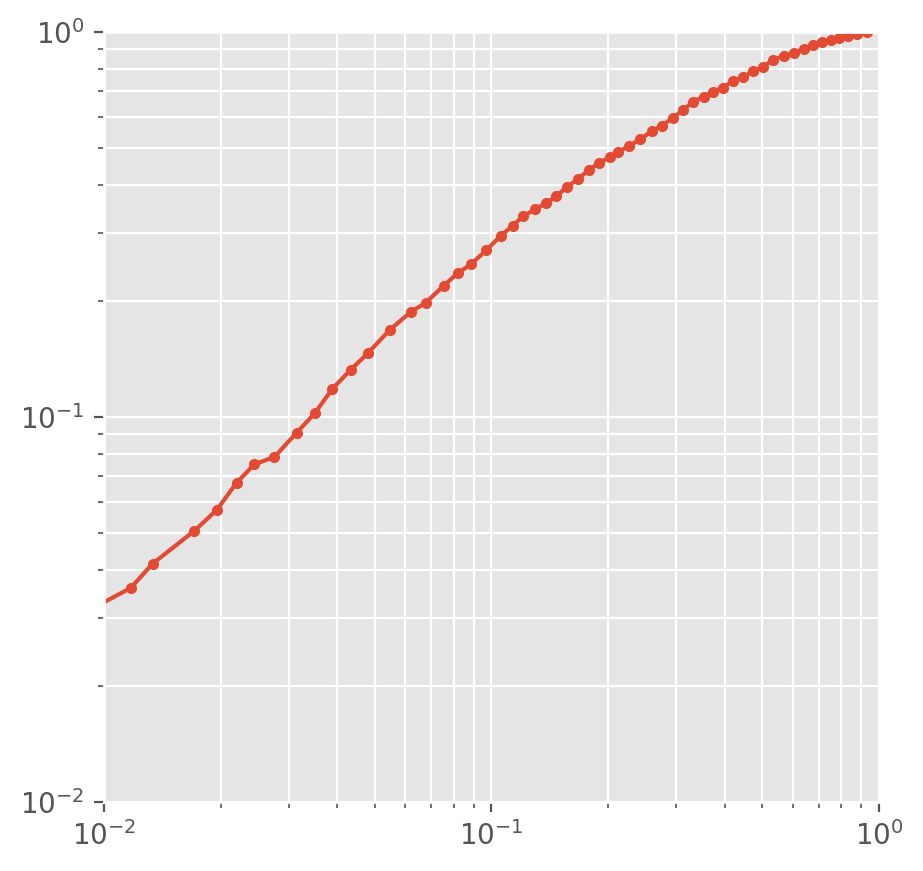

In [39]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.plot(c2, r2,'.-',)

ax.loglog()
ax.set_xlim([.01, 1])
ax.set_ylim([.01, 1])
ax.grid(visible=True, which='both')